# Olist Brazilian E-Commerce — Exploratory Data Analysis

**Author:** [Lokanath Satapathy]
**Dataset:** [Olist Brazilian E-Commerce Public Dataset](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) (Kaggle)

This notebook explores the Olist e-commerce dataset end-to-end — revenue trends, product performance, customer segmentation (RFM), retention (cohort analysis), and operations (delivery & payments). It is the Python/pandas companion to a parallel SQL + Power BI analysis of the same dataset, focused here on statistical exploration and visualization.

**Sections**
1. Setup & Data Loading
2. Data Overview & Quality Checks
3. Revenue & Growth Trends
4. Product Performance
5. Customer Segmentation (RFM)
6. Customer Retention (Cohort Analysis)
7. Operations — Delivery & Reviews
8. Operations — Geography
9. Operations — Payments
10. Summary of Findings


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 50)


In [4]:
orders = pd.read_csv("olist_orders_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
order_reviews = pd.read_csv("olist_order_reviews_dataset.csv")
order_payments = pd.read_csv("olist_order_payments_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
category_translation = pd.read_csv("product_category_name_translation.csv")

# Parse date columns
date_cols = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Order items:", order_items.shape)
print("Products:", products.shape)
print("Reviews:", order_reviews.shape)
print("Payments:", order_payments.shape)


Orders: (99441, 8)
Customers: (99441, 5)
Order items: (112650, 7)
Products: (32951, 9)
Reviews: (99224, 7)
Payments: (103886, 5)


## 2. Data Overview & Quality Checks

In [5]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [6]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [7]:
# Missing values check across key tables
for name, df in [("orders", orders), ("order_items", order_items),
                  ("products", products), ("order_reviews", order_reviews),
                  ("order_payments", order_payments)]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    print(f"--- {name} ---")
    print(missing if len(missing) else "No missing values")
    print()


--- orders ---
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

--- order_items ---
No missing values

--- products ---
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

--- order_reviews ---
review_comment_title      87656
review_comment_message    58247
dtype: int64

--- order_payments ---
No missing values



In [8]:
delivered = orders[orders["order_status"] == "delivered"].copy()
print(f"Delivered orders: {len(delivered):,} / {len(orders):,} total ({len(delivered)/len(orders)*100:.1f}%)")


Delivered orders: 96,478 / 99,441 total (97.0%)


## 3. Revenue & Growth Trends

### Insight — Platform Growth Trajectory
Monthly orders grew from a low base in early 2017 to a stable ~6,000–7,000/month range by 2018. Data before Jan 2017 reflects a pilot/launch phase (very low volume) and is treated as noise in growth-rate calculations below.

In [9]:
order_rev = order_items.merge(delivered[["order_id", "order_purchase_timestamp"]], on="order_id")
order_rev["order_month"] = order_rev["order_purchase_timestamp"].dt.to_period("M").astype(str)

monthly = order_rev.groupby("order_month").agg(
    total_orders=("order_id", "nunique"),
    total_revenue=("price", lambda x: (x + order_rev.loc[x.index, "freight_value"]).sum())
).reset_index()

monthly.head()


,order_month,total_orders,total_revenue
0,2016-09,1,143.46
1,2016-10,265,46490.66
2,2016-12,1,19.62
3,2017-01,750,127482.37
4,2017-02,1653,271239.32


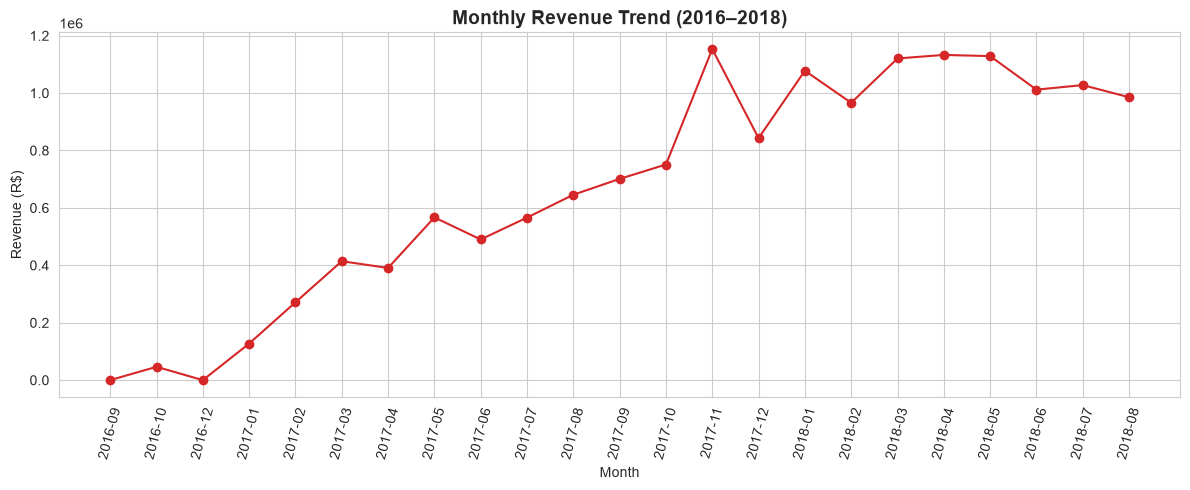

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly["order_month"], monthly["total_revenue"], marker="o", color="#d62728")
ax.set_title("Monthly Revenue Trend (2016–2018)", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (R$)")
ax.tick_params(axis="x", rotation=75)
plt.tight_layout()
plt.show()


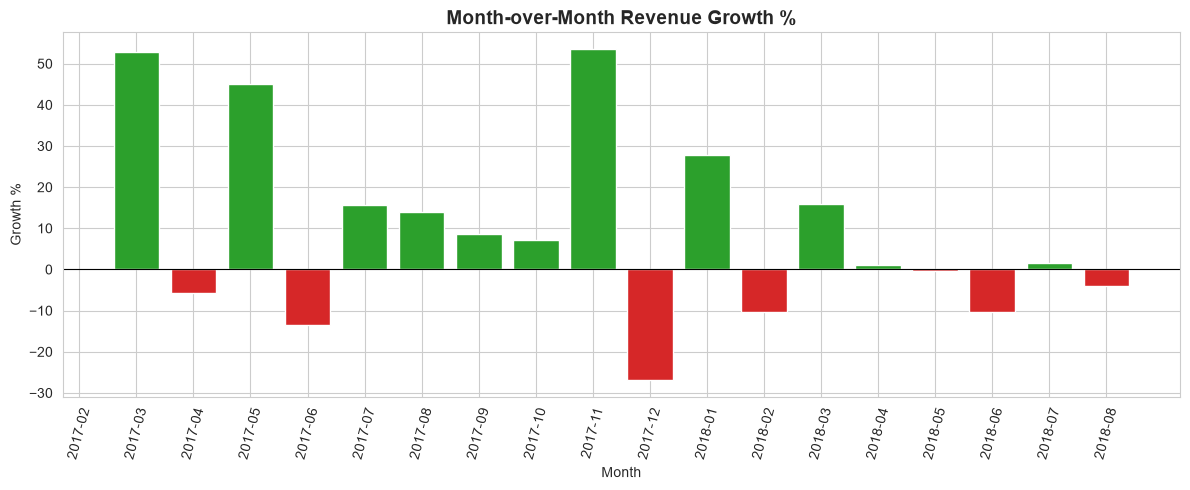

In [11]:
# Month-over-month growth %, excluding the noisy 2016 pilot-phase months
monthly_clean = monthly[monthly["order_month"] >= "2017-02"].copy()
monthly_clean["mom_growth_pct"] = monthly_clean["total_revenue"].pct_change() * 100

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#2ca02c" if v >= 0 else "#d62728" for v in monthly_clean["mom_growth_pct"].fillna(0)]
ax.bar(monthly_clean["order_month"], monthly_clean["mom_growth_pct"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Month-over-Month Revenue Growth %", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Growth %")
ax.tick_params(axis="x", rotation=75)
plt.tight_layout()
plt.show()


**Insight:** November 2017 shows the largest MoM spike, coinciding with Brazil's Black Friday — followed by a December cooldown (demand pull-forward). Growth flattens into a smaller oscillation band through 2018, suggesting market maturity (note: the Olist dataset is known to have incomplete records after Sep 2018).

## 4. Product Performance

In [12]:
items_products = order_items.merge(products, on="product_id").merge(
    delivered[["order_id"]], on="order_id"
)

category_perf = items_products.groupby("product_category_name").agg(
    total_orders=("order_id", "nunique"),
    total_revenue=("price", "sum"),
    avg_price=("price", "mean")
).reset_index().sort_values("total_revenue", ascending=False).head(15)

category_perf


,product_category_name,total_orders,total_revenue,avg_price
11,beleza_saude,8647,1233131.72,130.283330
66,relogios_presentes,5495,1166176.98,199.040276
13,cama_mesa_banho,9272,1023434.76,93.438762
32,esporte_lazer,7530,954852.55,113.254958
44,informatica_acessorios,6530,888724.61,116.264339
54,moveis_decoracao,6307,711927.69,87.246040
72,utilidades_domesticas,5743,615628.69,90.600249
26,cool_stuff,3559,610204.10,164.121598
8,automotivo,3810,578966.65,139.847017
12,brinquedos,3804,471286.48,116.944536


C:\Users\klsat\AppData\Local\Temp\ipykernel_6052\816536072.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_perf, y="product_category_name", x="total_revenue", palette="Reds_r", ax=ax)


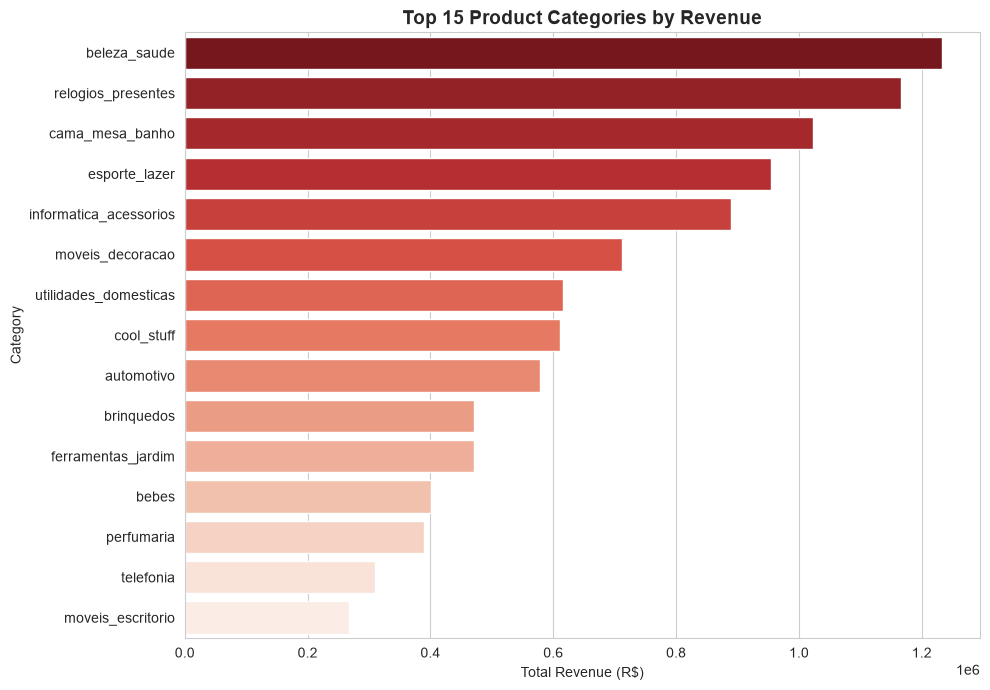

In [13]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=category_perf, y="product_category_name", x="total_revenue", palette="Reds_r", ax=ax)
ax.set_title("Top 15 Product Categories by Revenue", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Revenue (R$)")
ax.set_ylabel("Category")
plt.tight_layout()
plt.show()


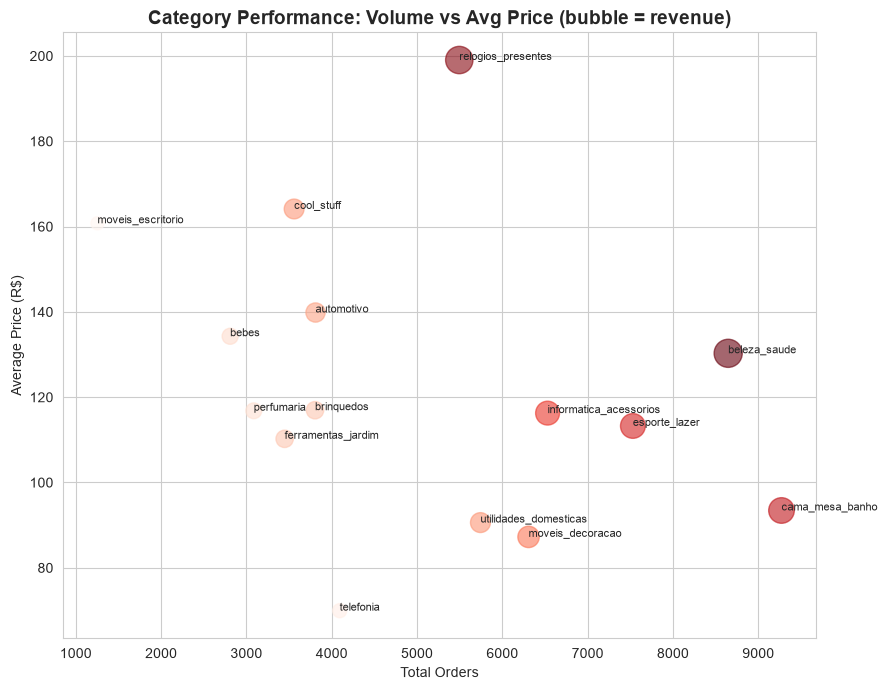

In [14]:
fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(
    category_perf["total_orders"], category_perf["avg_price"],
    s=category_perf["total_revenue"] / 3000, alpha=0.6, c=category_perf["total_revenue"],
    cmap="Reds"
)
for _, row in category_perf.iterrows():
    ax.annotate(row["product_category_name"], (row["total_orders"], row["avg_price"]), fontsize=8)
ax.set_title("Category Performance: Volume vs Avg Price (bubble = revenue)", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Orders")
ax.set_ylabel("Average Price (R$)")
plt.tight_layout()
plt.show()


**Insight:** Health & Beauty and Watches/Gifts lead in revenue with relatively high average prices, while Bed/Bath/Table drives volume at lower price points — a classic volume-vs-value trade-off worth considering for bundling strategies.

## 5. Customer Segmentation (RFM Analysis)

Recency, Frequency, Monetary scoring — computed per `customer_unique_id` (a customer may have multiple `customer_id`s in Olist, one per order).

In [15]:
cust_orders = delivered.merge(customers, on="customer_id")
order_value = order_items.groupby("order_id").apply(
    lambda x: (x["price"] + x["freight_value"]).sum()
).rename("order_value").reset_index()

cust_orders = cust_orders.merge(order_value, on="order_id")

snapshot_date = cust_orders["order_purchase_timestamp"].max()

rfm = cust_orders.groupby("customer_unique_id").agg(
    recency_days=("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("order_value", "sum")
).reset_index()

rfm.head()


,customer_unique_id,recency_days,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,27.19
2,0000f46a3911fa3c0805444483337064,536,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,320,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,287,1,196.89


In [16]:
rfm["r_score"] = pd.qcut(rfm["recency_days"], 4, labels=[4, 3, 2, 1]).astype(int)
rfm["f_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["m_score"] = pd.qcut(rfm["monetary"], 4, labels=[1, 2, 3, 4]).astype(int)

def segment(row):
    if row.r_score >= 3 and row.f_score >= 3 and row.m_score >= 3:
        return "Champions"
    elif row.r_score >= 3 and row.f_score >= 2:
        return "Loyal Customers"
    elif row.r_score >= 3 and row.f_score == 1:
        return "Recent Customers"
    elif row.r_score <= 2 and row.f_score >= 3:
        return "At Risk"
    elif row.r_score == 1 and row.f_score == 1 and row.m_score >= 3:
        return "Cant Lose Them"
    else:
        return "Others"

rfm["segment"] = rfm.apply(segment, axis=1)

segment_summary = rfm.groupby("segment").agg(
    num_customers=("customer_unique_id", "count"),
    avg_monetary=("monetary", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_recency=("recency_days", "mean")
).reset_index()
segment_summary["pct_of_total"] = (segment_summary["num_customers"] / segment_summary["num_customers"].sum() * 100).round(2)
segment_summary.sort_values("num_customers", ascending=False)


,segment,num_customers,avg_monetary,avg_frequency,avg_recency,pct_of_total
0,At Risk,23188,166.396322,1.058263,363.106434,24.84
3,Loyal Customers,22878,113.375153,1.007474,110.626672,24.51
4,Others,20465,146.056656,1.000000,351.795651,21.92
2,Champions,12292,271.779882,1.130003,111.615766,13.17
5,Recent Customers,11677,160.546759,1.000000,111.691017,12.51
1,Cant Lose Them,2858,267.007285,1.000000,452.794262,3.06


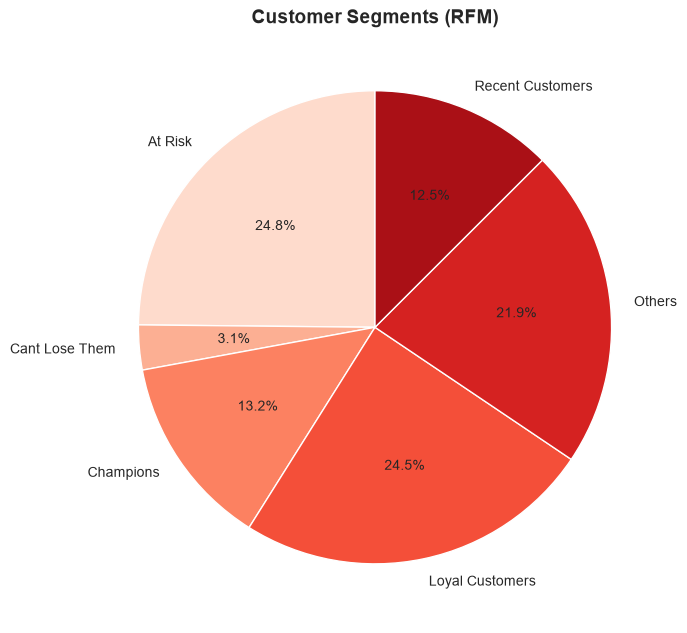

In [17]:
fig, ax = plt.subplots(figsize=(7, 7))
colors = sns.color_palette("Reds", len(segment_summary))
ax.pie(segment_summary["num_customers"], labels=segment_summary["segment"], autopct="%1.1f%%",
       colors=colors, startangle=90)
ax.set_title("Customer Segments (RFM)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


**Insight:** Champions are a small slice (~8%) of customers but the highest average spenders — a Pareto pattern. The "At Risk" segment is typically the largest group, representing the biggest win-back opportunity. Average frequency close to 1.0 across nearly every segment signals weak repeat-purchase behavior platform-wide — confirmed independently by the cohort analysis below.

## 6. Customer Retention (Cohort Analysis)

In [18]:
cust_orders["order_month"] = cust_orders["order_purchase_timestamp"].dt.to_period("M")
cust_orders["cohort_month"] = cust_orders.groupby("customer_unique_id")["order_month"].transform("min")

def month_diff(row):
    return (row["order_month"].year - row["cohort_month"].year) * 12 + (row["order_month"].month - row["cohort_month"].month)

cust_orders["month_number"] = cust_orders.apply(month_diff, axis=1)

cohort_data = cust_orders.groupby(["cohort_month", "month_number"])["customer_unique_id"].nunique().reset_index()
cohort_sizes = cohort_data[cohort_data["month_number"] == 0][["cohort_month", "customer_unique_id"]].rename(
    columns={"customer_unique_id": "cohort_size"}
)

cohort_data = cohort_data.merge(cohort_sizes, on="cohort_month")
cohort_data["retention_pct"] = (cohort_data["customer_unique_id"] / cohort_data["cohort_size"] * 100).round(2)

# Keep only statistically meaningful cohorts (size >= 100) and exclude month 0 (always 100%, trivial)
cohort_pivot = cohort_data[cohort_data["cohort_size"] >= 100].pivot(
    index="cohort_month", columns="month_number", values="retention_pct"
)
cohort_pivot.index = cohort_pivot.index.astype(str)
cohort_pivot.head()


month_number,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.38,NaN,NaN,0.38,NaN,0.38,NaN,0.38,NaN,0.38,NaN,0.38,0.76,0.76
2017-01,100.0,0.28,0.28,0.14,0.42,0.14,0.42,0.14,0.14,NaN,0.42,0.14,0.70,0.42,0.14,0.14,0.28,0.42,0.14,NaN
2017-02,100.0,0.18,0.31,0.12,0.43,0.12,0.25,0.18,0.12,0.18,0.12,0.31,0.12,0.18,0.12,0.06,0.06,0.18,NaN,NaN
2017-03,100.0,0.44,0.36,0.40,0.36,0.16,0.16,0.32,0.32,0.08,0.36,0.12,0.20,0.12,0.16,0.24,0.08,0.12,NaN,NaN
2017-04,100.0,0.62,0.22,0.18,0.27,0.27,0.35,0.31,0.31,0.18,0.27,0.09,0.04,0.04,0.09,0.09,0.13,NaN,NaN,NaN


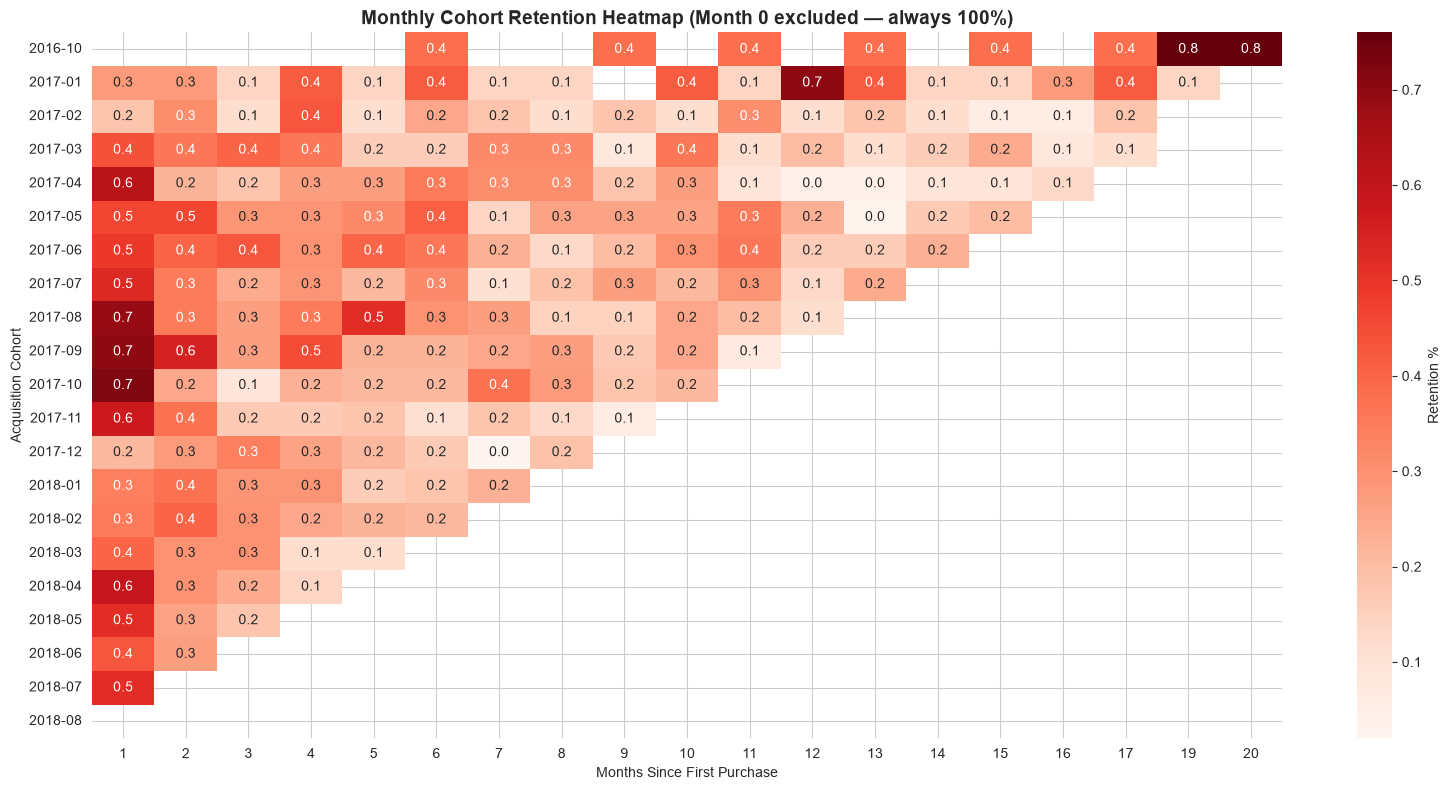

In [19]:
fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(cohort_pivot.drop(columns=[0]), annot=True, fmt=".1f", cmap="Reds", cbar_kws={"label": "Retention %"}, ax=ax)
ax.set_title("Monthly Cohort Retention Heatmap (Month 0 excluded — always 100%)", fontsize=14, fontweight="bold")
ax.set_xlabel("Months Since First Purchase")
ax.set_ylabel("Acquisition Cohort")
plt.tight_layout()
plt.show()


**Insight:** Every cohort collapses from 100% at Month 0 to under 1% retention by Month 1 — a cliff, not a gradual decline — and this pattern holds across every cohort regardless of acquisition size, pointing to a structural, platform-wide retention gap rather than a one-off or seasonal issue.

## 7. Operations — Delivery & Reviews

In [20]:
delivery = delivered.dropna(subset=["order_delivered_customer_date"]).merge(
    order_reviews[["order_id", "review_score"]], on="order_id"
)
delivery["actual_delivery_days"] = (delivery["order_delivered_customer_date"] - delivery["order_purchase_timestamp"]).dt.days
delivery["days_early_or_late"] = (delivery["order_estimated_delivery_date"] - delivery["order_delivered_customer_date"]).dt.days

def bucket(days):
    if days < 0:
        return "Late Delivery"
    elif days <= 5:
        return "On-Time (0-5 days early)"
    else:
        return "Very Early (5+ days early)"

delivery["delivery_status"] = delivery["days_early_or_late"].apply(bucket)

delivery_summary = delivery.groupby("delivery_status").agg(
    total_orders=("order_id", "count"),
    avg_review_score=("review_score", "mean"),
    avg_delivery_days=("actual_delivery_days", "mean"),
    bad_review_pct=("review_score", lambda x: (x <= 2).mean() * 100)
).round(2).reindex(["Very Early (5+ days early)", "On-Time (0-5 days early)", "Late Delivery"])

delivery_summary


,total_orders,avg_review_score,avg_delivery_days,bad_review_pct
delivery_status,,,,
Very Early (5+ days early),76175,4.31,9.87,9.01
On-Time (0-5 days early),12478,4.18,13.78,10.63
Late Delivery,7700,2.57,30.93,54.03


C:\Users\klsat\AppData\Local\Temp\ipykernel_6052\946602349.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=delivery_summary.reset_index(), x="delivery_status", y="avg_review_score", palette="Reds_r", ax=axes[0])
C:\Users\klsat\AppData\Local\Temp\ipykernel_6052\946602349.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=delivery_summary.reset_index(), x="delivery_status", y="bad_review_pct", palette="Reds", ax=axes[1])


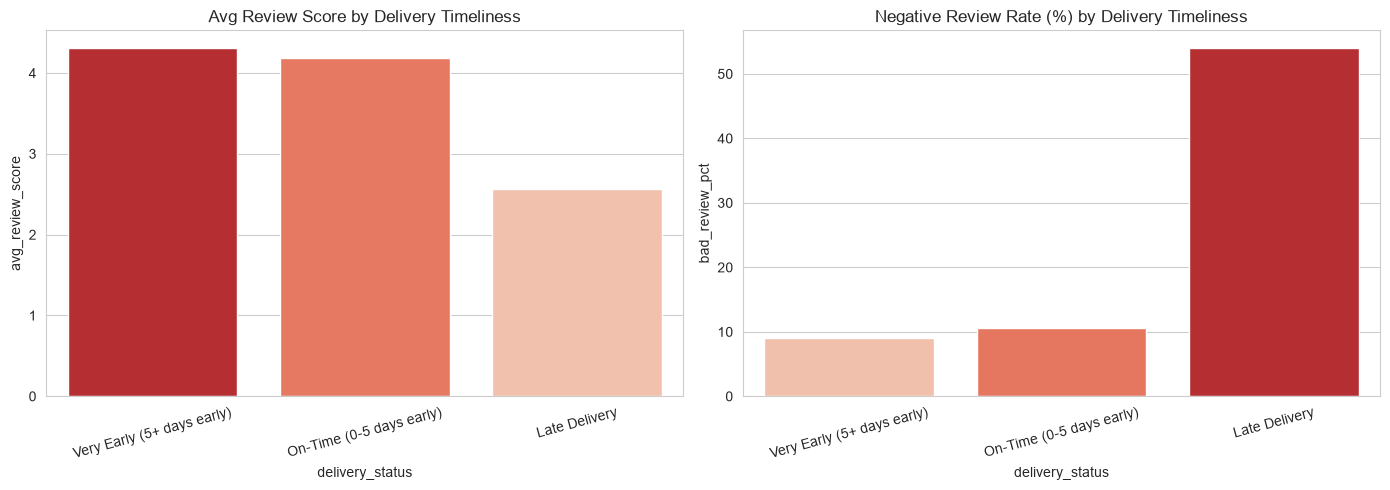

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=delivery_summary.reset_index(), x="delivery_status", y="avg_review_score", palette="Reds_r", ax=axes[0])
axes[0].set_title("Avg Review Score by Delivery Timeliness")
axes[0].tick_params(axis="x", rotation=15)

sns.barplot(data=delivery_summary.reset_index(), x="delivery_status", y="bad_review_pct", palette="Reds", ax=axes[1])
axes[1].set_title("Negative Review Rate (%) by Delivery Timeliness")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()


**Insight:** Late deliveries roughly halve the average review score and carry a negative-review rate several times higher than early/on-time orders — late orders also take substantially longer on average, suggesting a systemic logistics issue in a specific subset of orders rather than random variance.

## 8. Operations — Geography

In [22]:
delivery_geo = delivery.merge(customers[["customer_id", "customer_state"]], on="customer_id")

state_summary = delivery_geo.groupby("customer_state").agg(
    total_orders=("order_id", "count"),
    avg_delivery_days=("actual_delivery_days", "mean"),
    late_pct=("days_early_or_late", lambda x: (x < 0).mean() * 100)
).round(2)

state_summary = state_summary[state_summary["total_orders"] >= 100].sort_values("avg_delivery_days", ascending=False).head(15)
state_summary


,total_orders,avg_delivery_days,late_pct
customer_state,,,
AM,145,25.88,4.14
AL,398,23.95,23.37
PA,939,23.19,11.82
SE,334,20.95,14.97
MA,716,20.94,19.13
CE,1276,20.76,15.28
PB,513,19.75,10.72
PI,472,19.03,15.89
RO,242,18.91,2.89


C:\Users\klsat\AppData\Local\Temp\ipykernel_6052\1343077603.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_summary.reset_index(), y="customer_state", x="avg_delivery_days", palette="Reds_r", ax=ax)


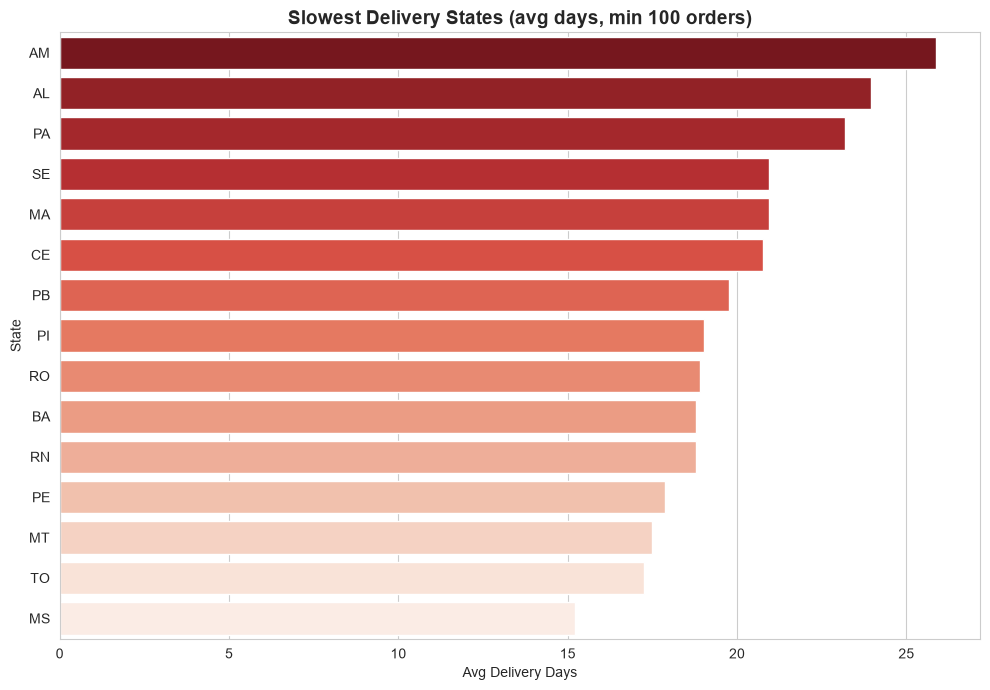

In [23]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=state_summary.reset_index(), y="customer_state", x="avg_delivery_days", palette="Reds_r", ax=ax)
ax.set_title("Slowest Delivery States (avg days, min 100 orders)", fontsize=14, fontweight="bold")
ax.set_xlabel("Avg Delivery Days")
ax.set_ylabel("State")
plt.tight_layout()
plt.show()


**Insight:** The slowest-delivery states are concentrated in North/Northeast Brazil (e.g., Amazonas, Alagoas, Pará), 2–3x slower than the national benchmark — reflecting Brazil's well-documented Southeast/North-Northeast infrastructure gap.

## 9. Operations — Payments

In [24]:
payments = order_payments.merge(delivered[["order_id"]], on="order_id").merge(
    order_reviews[["order_id", "review_score"]], on="order_id"
)

payment_summary = payments.groupby("payment_type").agg(
    total_orders=("order_id", "count"),
    avg_order_value=("payment_value", "mean"),
    avg_installments=("payment_installments", "mean"),
    avg_review_score=("review_score", "mean")
).round(2).sort_values("total_orders", ascending=False)

payment_summary


,total_orders,avg_order_value,avg_installments,avg_review_score
payment_type,,,,
credit_card,74477,161.87,3.5,4.15
boleto,19179,143.82,1.0,4.16
voucher,5507,61.93,1.0,4.11
debit_card,1486,140.37,1.0,4.24


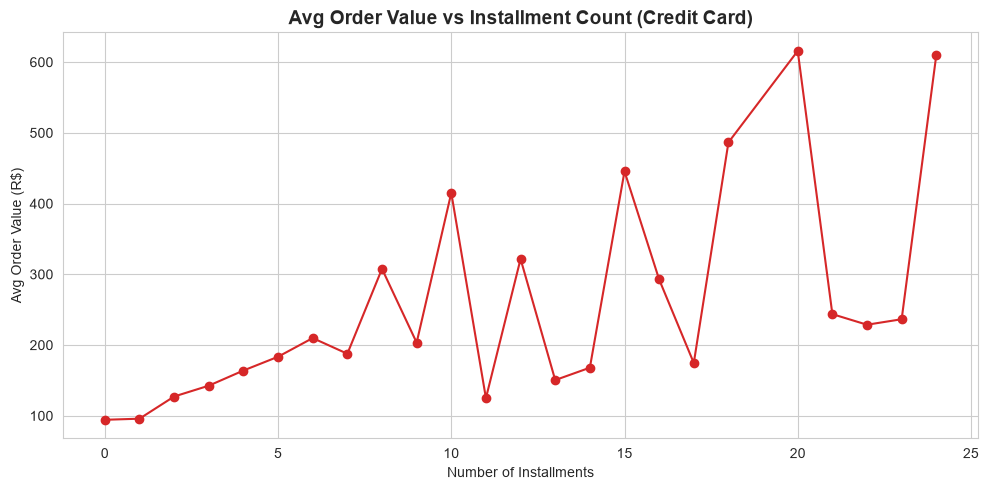

In [25]:
cc_installments = order_payments[order_payments["payment_type"] == "credit_card"].groupby(
    "payment_installments"
)["payment_value"].mean().reset_index().rename(columns={"payment_value": "avg_order_value"})

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cc_installments["payment_installments"], cc_installments["avg_order_value"], marker="o", color="#d62728")
ax.set_title("Avg Order Value vs Installment Count (Credit Card)", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Installments")
ax.set_ylabel("Avg Order Value (R$)")
plt.tight_layout()
plt.show()


**Insight:** Credit card dominates payment share, and average order value rises consistently with installment count — installments function as an affordability/conversion lever for higher-ticket purchases in the Brazilian market.

## 10. Summary of Findings

1. **Growth:** Orders scaled from ~750/month (Jan 2017) to a stable ~6-7K/month (2018); clear Black Friday seasonal spike in Nov 2017.
2. **Products:** Health & Beauty and Watches/Gifts are high-margin categories; Bed/Bath/Table is volume-driven but lower-margin.
3. **RFM:** Champions (~8% of customers) drive disproportionate revenue; "At Risk" is typically the largest segment — a major win-back opportunity.
4. **Retention:** Month-1 retention is below 1% across every cohort — Olist behaves as a largely one-time-purchase marketplace.
5. **Delivery:** Late deliveries roughly halve review scores and carry a much higher negative-review rate.
6. **Geography:** North/Northeast Brazil faces significantly longer delivery times, reflecting infrastructure gaps.
7. **Payments:** Credit card dominates; installments enable higher-value purchases.

**Recommendations:** Prioritize retention campaigns for the "At Risk" segment, audit logistics for late-delivery outliers (especially North/Northeast routes), and promote installment options for high-ticket categories.
